In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut,
    cross_validate, permutation_test_score,
)
from sklearn.metrics import (
    make_scorer, f1_score, precision_score,
    recall_score, roc_auc_score, RocCurveDisplay,
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
FEAT_TABLE_BASE = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
FEAT_TABLE      = os.path.join(FEAT_TABLE_BASE, "feat_table_500ns.xlsx")
REPO_DIR        = "/Users/ivanatang/Developer/biosensors"
MD_CANDIDATE_GUIDE = os.path.join(REPO_DIR, "md_candidate_guide.csv")

# ── seq_source cohort filter ────────────────────────────────────────────────
# "all" trains/tests on the full assembled cohort. "ngs_observed" restricts to
# sequences whose md_candidate_guide.csv `source` == "ngs_observed" (sequencing-
# confirmed designs via Y2H/FACS sort-seq; depth>=10, P_bind/P_const thresholds),
# excluding "designed_assumed" candidates that only passed computational
# structure-prediction QC with no experimental confirmation. Legacy
# seq*_binder/seq*_nb sequences predate md_candidate_guide.csv and have no
# source entry -- excluded from "ngs_observed" (provenance unconfirmed) but
# retained under "all". Mirrors the filter in ML_classification.ipynb.
SEQ_SOURCE = "ngs_observed"   # "all" | "ngs_observed"

MD_GROUP_SUFFIX = {
    "binder":              "_binder",
    "non_binder":          "_nb",
    "negative_low_pocket": "_low_pkt",
    "negative_fail_gate":  "_fail_gate",
}

OUT_DIR = os.path.join(REPO_DIR, "sequence_baselines", SEQ_SOURCE)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Amino acid constants ───────────────────────────────────────────────────────
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
AA_INDEX = {aa: i for i, aa in enumerate(AA_ORDER)}

# ── Residue molecular weights (Da) ────────────────────────────────────────────
# Residue MW = amino acid MW − H₂O (18.015 Da); Source: NIST
RESIDUE_MW = {
    "A":  71.078, "C": 103.144, "D": 115.089, "E": 129.116,
    "F": 147.177, "G":  57.052, "H": 137.141, "I": 113.159,
    "K": 128.174, "L": 113.159, "M": 131.197, "N": 114.104,
    "P":  97.116, "Q": 128.131, "R": 156.188, "S":  87.078,
    "T": 101.105, "V":  99.132, "W": 186.213, "Y": 163.176,
    "X":   0.000,
}

# ── Physicochemical property table ─────────────────────────────────────────────
# 7 properties: [hydrophobicity, charge, mol_weight, vdw_volume,
#                aromaticity, hb_donors, hb_acceptors]
# Sources: Kyte & Doolittle (1982); Pontius et al. (1996)
PCP_PROPS = {
    "A": [ 1.800, 0.0,  89.09,  88.6, 0, 1, 1],
    "C": [ 2.500, 0.0, 121.16, 108.5, 0, 2, 1],
    "D": [-3.500,-1.0, 133.10, 111.1, 0, 1, 3],
    "E": [-3.500,-1.0, 147.13, 138.4, 0, 1, 3],
    "F": [ 2.800, 0.0, 165.19, 189.9, 1, 1, 1],
    "G": [-0.400, 0.0,  75.03,  60.1, 0, 1, 1],
    "H": [-3.200, 0.0, 155.16, 153.2, 1, 3, 2],
    "I": [ 4.500, 0.0, 131.17, 166.7, 0, 1, 1],
    "K": [-3.900, 1.0, 146.19, 168.6, 0, 3, 1],
    "L": [ 3.800, 0.0, 131.17, 166.7, 0, 1, 1],
    "M": [ 1.900, 0.0, 149.21, 162.9, 0, 1, 2],
    "N": [-3.500, 0.0, 132.12, 114.1, 0, 2, 2],
    "P": [-1.600, 0.0, 115.13, 112.7, 0, 0, 1],
    "Q": [-3.500, 0.0, 146.15, 143.8, 0, 2, 2],
    "R": [-4.500, 1.0, 174.20, 173.4, 0, 5, 1],
    "S": [-0.800, 0.0, 105.09,  89.0, 0, 2, 2],
    "T": [-0.700, 0.0, 119.12, 116.1, 0, 2, 2],
    "V": [ 4.200, 0.0, 117.15, 140.0, 0, 1, 1],
    "W": [-0.900, 0.0, 204.23, 227.8, 1, 2, 1],
    "Y": [-1.300, 0.0, 181.19, 193.6, 1, 2, 2],
}
PCP_NAMES = ["hydrophobicity", "charge", "mol_weight",
             "vdw_volume", "aromaticity", "hb_donors", "hb_acceptors"]
N_PROPS = len(PCP_NAMES)
_arr = np.array([PCP_PROPS[aa] for aa in AA_ORDER], dtype=np.float32)
_min = _arr.min(axis=0)
_rng = _arr.max(axis=0) - _arr.min(axis=0)
_rng[_rng == 0] = 1.0
PCP_NORMED = {aa: (np.array(PCP_PROPS[aa], dtype=np.float32) - _min) / _rng
              for aa in AA_ORDER}
PCP_NORMED["X"] = np.zeros(N_PROPS, dtype=np.float32)

# ── MW pocket positions (1-indexed) ───────────────────────────────────────────
# Leave empty [] to auto-detect variable positions by Shannon entropy.
# Override to restrict to known PYR1 pocket residues, e.g.:
#   POCKET_POSITIONS = [83, 92, 94, 108, 117, 120, 122, 159, 160, 163, 164, 167]
POCKET_POSITIONS = []

# ── Group labels ───────────────────────────────────────────────────────────────
BINARY_LABEL = {
    "binder":    1,
    "nonbinder": 0,
    "low_pkt":   0,
    "fail_gate": 0,
}
DISPLAY_LABEL = {
    "binder":    "Binder",
    "nonbinder": "False Positive",
    "low_pkt":   "Low Confidence",
    "fail_gate": "Fail Geometry",
}
GROUP_COLORS = {
    "binder":    "#648FFF",
    "nonbinder": "#DC267F",
    "low_pkt":   "#FE6100",
    "fail_gate": "#FFB000",
}

# ── Encoding colors (for comparison plots) ────────────────────────────────────
ENC_COLORS = {"OHE": "#4C72B0", "PCP": "#DD8452", "MW": "#55A868"}

RANDOM_STATE = 42
N_SPLITS     = 7


In [3]:
# ── Shared: variable position detection ───────────────────────────────────────

def variable_positions(sequences, min_entropy=0.1):
    """Shannon entropy filter. Returns 0-indexed positions. Train-data only."""
    L = len(sequences[0])
    entropies = []
    for pos in range(L):
        counts = np.zeros(20)
        for seq in sequences:
            idx = AA_INDEX.get(seq[pos].upper())
            if idx is not None:
                counts[idx] += 1
        freq = counts / counts.sum() if counts.sum() > 0 else counts
        freq = freq[freq > 0]
        entropies.append(-np.sum(freq * np.log2(freq)) if len(freq) else 0)
    return np.where(np.array(entropies) >= min_entropy)[0]


# ── OHE encoder ───────────────────────────────────────────────────────────────

class OHEEncoder(BaseEstimator, TransformerMixin):
    """One-hot encoding at variable positions. No leakage: fit on train only."""
    def __init__(self, min_entropy=0.1):
        self.min_entropy = min_entropy
    def fit(self, sequences, y=None):
        self.var_pos_ = variable_positions(sequences, self.min_entropy)
        return self
    def transform(self, sequences):
        rows = []
        for seq in sequences:
            row = []
            for pos in self.var_pos_:
                vec = np.zeros(len(AA_ORDER), dtype=np.float32)
                idx = AA_INDEX.get(seq[pos].upper())
                if idx is not None:
                    vec[idx] = 1.0
                row.append(vec)
            rows.append(np.concatenate(row))
        return np.vstack(rows)
    def get_feature_names_out(self):
        return np.array([f"pos{p+1}_{aa}" for p in self.var_pos_ for aa in AA_ORDER])


# ── PCP encoder ───────────────────────────────────────────────────────────────

class PCPEncoder(BaseEstimator, TransformerMixin):
    """7 normalised physicochemical properties per variable position. No leakage."""
    def __init__(self, min_entropy=0.1):
        self.min_entropy = min_entropy
    def fit(self, sequences, y=None):
        self.var_pos_ = variable_positions(sequences, self.min_entropy)
        return self
    def transform(self, sequences):
        return np.vstack([
            np.concatenate([PCP_NORMED.get(seq[p].upper(), PCP_NORMED["X"])
                            for p in self.var_pos_])
            for seq in sequences
        ])
    def get_feature_names_out(self):
        return np.array([f"pos{p+1}_{prop}" for p in self.var_pos_ for prop in PCP_NAMES])


# ── MW encoder ────────────────────────────────────────────────────────────────

class MWEncoder(BaseEstimator, TransformerMixin):
    """Residue MW (Da) at pocket/variable positions. No leakage."""
    def __init__(self, pocket_positions=None, min_entropy=0.1):
        self.pocket_positions = pocket_positions
        self.min_entropy      = min_entropy
    def fit(self, sequences, y=None):
        if self.pocket_positions:
            self.pos_ = np.array(self.pocket_positions, dtype=int) - 1
        else:
            self.pos_ = variable_positions(sequences, self.min_entropy)
        return self
    def transform(self, sequences):
        return np.array(
            [[RESIDUE_MW.get(seq[p].upper(), 0.0) for p in self.pos_]
             for seq in sequences], dtype=np.float32
        )
    def get_feature_names_out(self):
        return np.array([f"MW_pos{p+1}" for p in self.pos_])


# ── Data loader ────────────────────────────────────────────────────────────────

def load_feat_table(path, seq_source=SEQ_SOURCE):
    df = pd.read_excel(path, sheet_name="all_feats_500ns")
    df.columns = df.columns.str.strip()
    rename = {}
    for col in df.columns:
        if col.lower() == "sequence": rename[col] = "sequence"
        if col.lower() == "group":    rename[col] = "group"
        if col.lower() == "name":     rename[col] = "name"
    df = df.rename(columns=rename)
    df["group"]    = df["group"].astype(str).str.strip().str.lower()
    df["sequence"] = df["sequence"].astype(str).str.strip()
    df = df[df["group"].isin(BINARY_LABEL)].reset_index(drop=True)
    df = df[df["sequence"].str.len() > 0].reset_index(drop=True)
    n_base = len(df)

    # ── seq_source cohort filter (see SEQ_SOURCE comment in the paths cell) ──
    mcg = pd.read_csv(MD_CANDIDATE_GUIDE)
    mcg["name"] = mcg["pair_id"].astype(str) + mcg["md_group"].map(MD_GROUP_SUFFIX)
    df = df.merge(mcg[["name", "source"]], on="name", how="left")
    n_no_source = int(df["source"].isna().sum())
    print(f"  seq_source coverage : {n_base - n_no_source}/{n_base} matched to md_candidate_guide.csv "
          f"({n_no_source} legacy/unlisted -> source unknown)")

    if seq_source == "ngs_observed":
        df = df[df["source"] == "ngs_observed"].reset_index(drop=True)
    elif seq_source != "all":
        raise ValueError(f"Unknown seq_source={seq_source!r}, expected 'all' or 'ngs_observed'")

    print(f"Loaded {len(df)} sequences (seq_source={seq_source!r})")
    print(df["group"].value_counts().to_string())
    return df


# ── Pipeline builders ──────────────────────────────────────────────────────────

def build_rf():
    return RandomForestClassifier(
        n_estimators=500, max_features="sqrt",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_ohe_pipe():
    return Pipeline([("enc", OHEEncoder()), ("rf", build_rf())])

def make_pcp_pipe():
    return Pipeline([("enc", PCPEncoder()), ("rf", build_rf())])

def make_mw_pipe():
    return Pipeline([
        ("enc", MWEncoder(pocket_positions=POCKET_POSITIONS if POCKET_POSITIONS else None)),
        ("rf",  build_rf()),
    ])


# ── Shared evaluation helpers ──────────────────────────────────────────────────

scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                make_scorer(f1_score,        zero_division=0),
    "precision":         make_scorer(precision_score, zero_division=0),
    "recall":            make_scorer(recall_score,    zero_division=0),
}

def run_cv(pipe_fn, sequences, y):
    """7-fold CV + permutation test. Returns metrics_df, obs_score, pval, perm_scores."""
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_results = cross_validate(
        pipe_fn(), sequences, y, cv=cv,
        scoring=scoring, return_train_score=False,
    )
    metrics = {k.replace("test_", ""): v
               for k, v in cv_results.items() if k.startswith("test_")}
    metrics_df = pd.DataFrame({
        k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
        for k, v in metrics.items()
    }).T
    obs, perm_scores, pval = permutation_test_score(
        pipe_fn(), sequences, y, cv=cv, scoring="balanced_accuracy",
        n_permutations=100, random_state=RANDOM_STATE, n_jobs=1,
    )
    return metrics_df, obs, pval, perm_scores


def run_loocv(pipe_fn, sequences, y):
    """LOO-CV; returns per-sample predicted probabilities."""
    loo   = LeaveOneOut()
    proba = np.zeros(len(y))
    for tr, te in loo.split(sequences, y):
        seq_tr = [sequences[i] for i in tr]
        seq_te = [sequences[i] for i in te]
        proba[te] = pipe_fn().fit(seq_tr, y[tr]).predict_proba(seq_te)[:, 1]
    return proba


def feature_importance_plot(pipe_fitted, label, out_suffix, n_per_pos):
    """Per-feature and per-position importance bar charts."""
    enc   = pipe_fitted.named_steps["enc"]
    imp   = pipe_fitted.named_steps["rf"].feature_importances_
    names = enc.get_feature_names_out()
    pos   = enc.var_pos_ if hasattr(enc, "var_pos_") else enc.pos_

    top_n   = min(50, len(imp))
    top_idx = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(range(top_n), imp[top_idx], color="steelblue", alpha=0.8)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([names[i] for i in top_idx], rotation=90, fontsize=7)
    ax.set_ylabel("Gini Importance")
    ax.set_title(f"{label} — Top {top_n} Feature Importances (full-data RF)")
    ax.grid(True, alpha=0.4, axis="y")
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"feature_importances_{out_suffix}.png"), dpi=150)
    plt.show()

    pos_imp = imp.reshape(len(pos), n_per_pos).sum(axis=1)
    top_pos = np.argsort(pos_imp)[::-1][:20]
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.bar(range(len(top_pos)), pos_imp[top_pos], color="darkorange", alpha=0.8)
    ax2.set_xticks(range(len(top_pos)))
    ax2.set_xticklabels([f"pos {pos[p]+1}" for p in top_pos], rotation=90)
    ax2.set_ylabel("Summed Importance")
    ax2.set_title(f"{label} — Top 20 Positions by Aggregated Importance")
    ax2.grid(True, alpha=0.4, axis="y")
    plt.tight_layout()
    fig2.savefig(os.path.join(OUT_DIR, f"position_importances_{out_suffix}.png"), dpi=150)
    plt.show()


  seq_source coverage : 114/127 matched to md_candidate_guide.csv (13 legacy/unlisted -> source unknown)
Loaded 95 sequences (seq_source='ngs_observed')
group
nonbinder    48
binder       47
Binary class counts:  Binder=47  Non-binder=48

--- Fold composition (n_splits=7) ---
  Fold 1: train = 40 binders / 41 nonbinders  |  test = 7 binders / 7 nonbinders
  Fold 2: train = 40 binders / 41 nonbinders  |  test = 7 binders / 7 nonbinders
  Fold 3: train = 40 binders / 41 nonbinders  |  test = 7 binders / 7 nonbinders
  Fold 4: train = 40 binders / 41 nonbinders  |  test = 7 binders / 7 nonbinders
  Fold 5: train = 40 binders / 42 nonbinders  |  test = 7 binders / 6 nonbinders
  Fold 6: train = 41 binders / 41 nonbinders  |  test = 6 binders / 7 nonbinders
  Fold 7: train = 41 binders / 41 nonbinders  |  test = 6 binders / 7 nonbinders

OHE feature dims : 16 pos × 20 AAs   = 320
PCP feature dims : 16 pos × 7 props = 112
MW  feature dims : 16 pos × 1 scalar = 16

--- OHE: running CV ---


                    Mean     SD
accuracy           0.725  0.128
balanced_accuracy  0.724  0.128
roc_auc            0.833  0.097
f1                 0.710  0.145
precision          0.733  0.137
recall             0.701  0.178
Permutation p-val: 0.010

--- PCP: running CV ---


                    Mean     SD
accuracy           0.790  0.127
balanced_accuracy  0.789  0.126
roc_auc            0.889  0.087
f1                 0.773  0.143
precision          0.814  0.125
recall             0.748  0.185
Permutation p-val: 0.010

--- MW: running CV ---


                    Mean     SD
accuracy           0.779  0.118
balanced_accuracy  0.779  0.117
roc_auc            0.879  0.082
f1                 0.763  0.135
precision          0.798  0.125
recall             0.748  0.185
Permutation p-val: 0.010

--- Running LOO-CV for all three encodings ---


OHE LOO-CV AUC: 0.8639
PCP LOO-CV AUC: 0.9040
MW  LOO-CV AUC: 0.8901


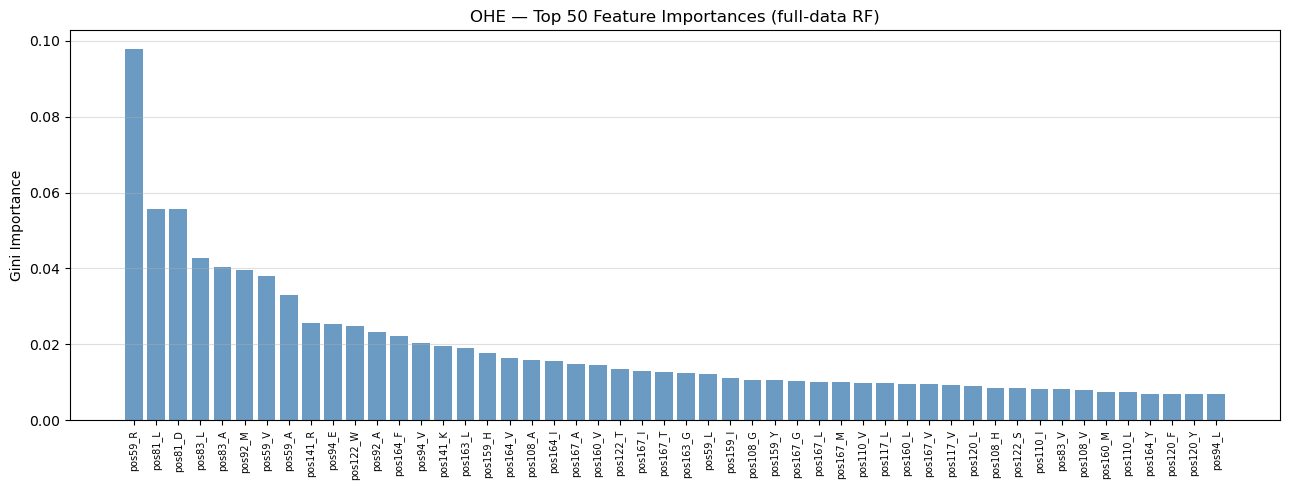

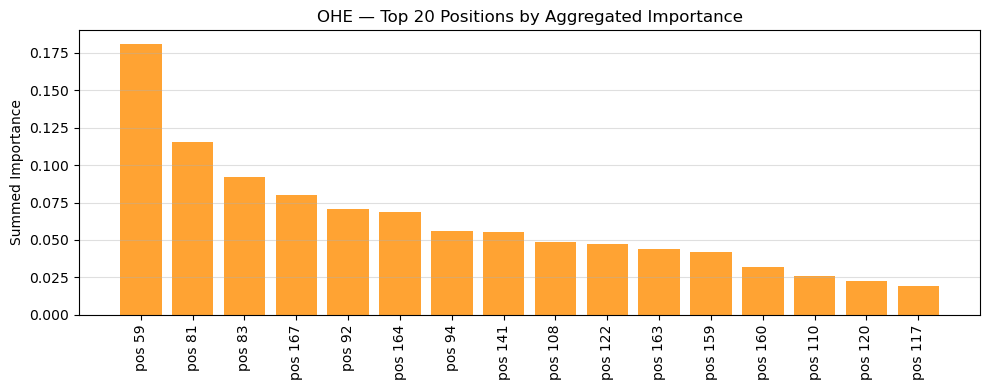

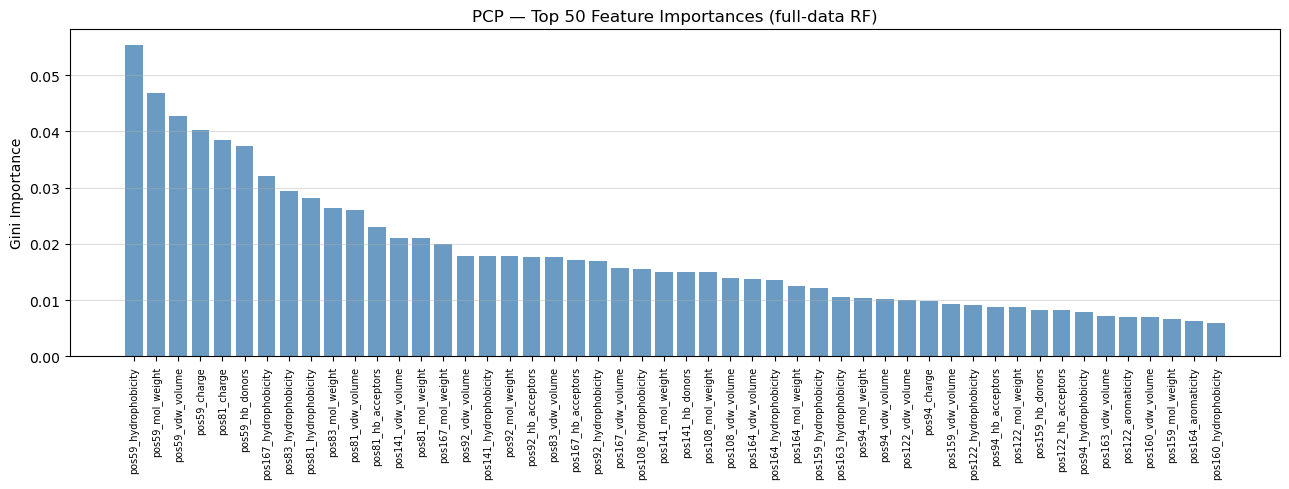

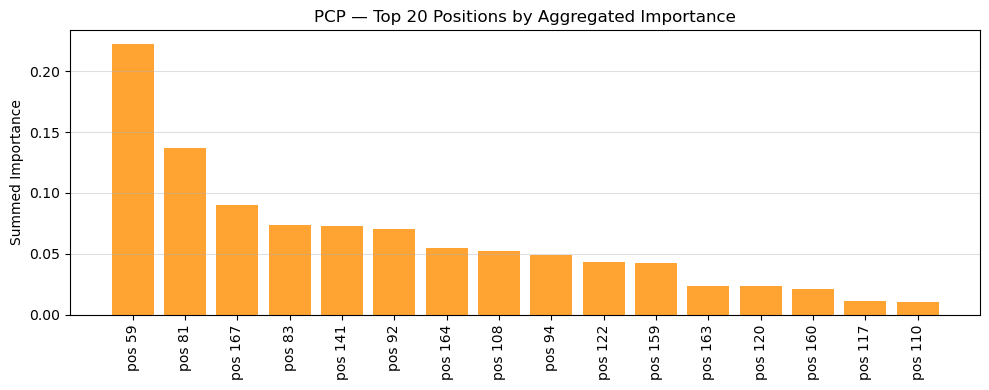

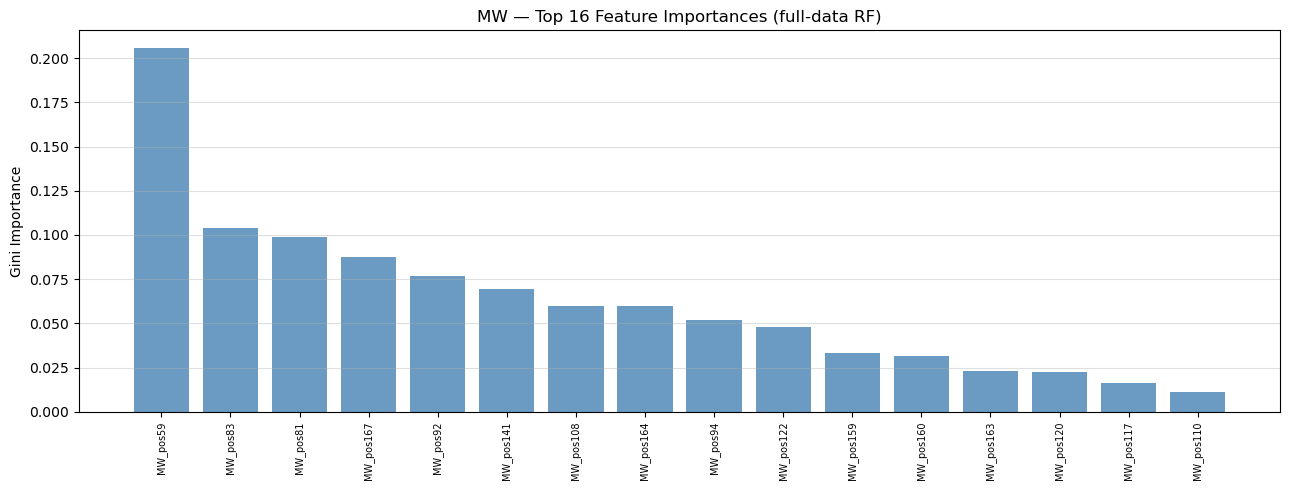

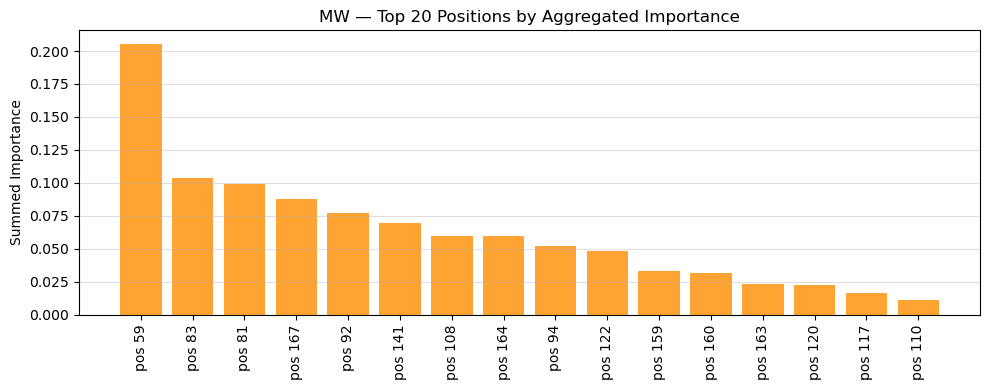

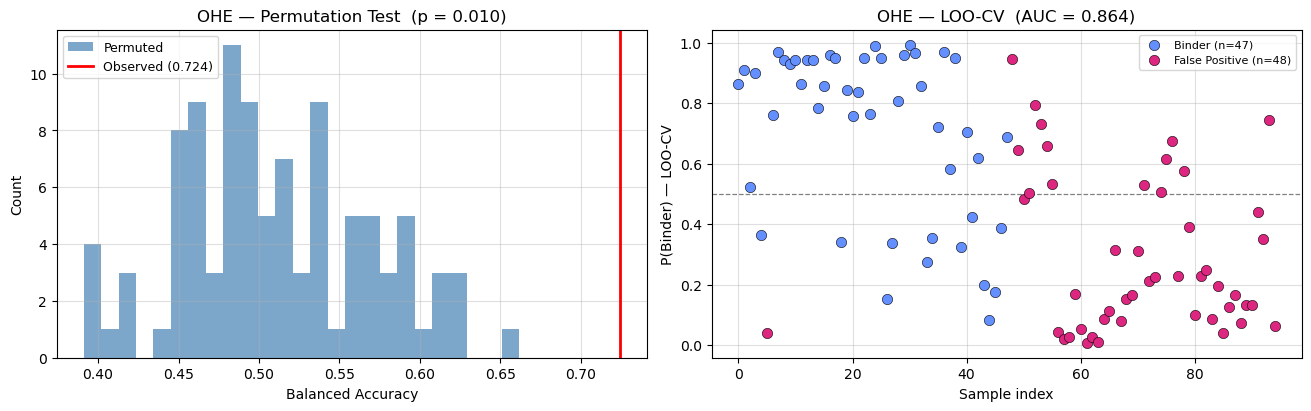

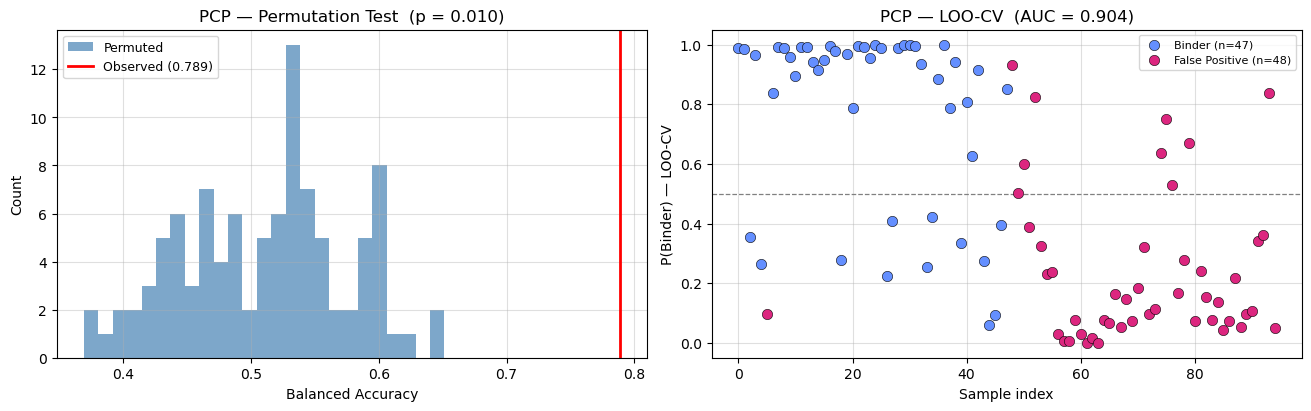

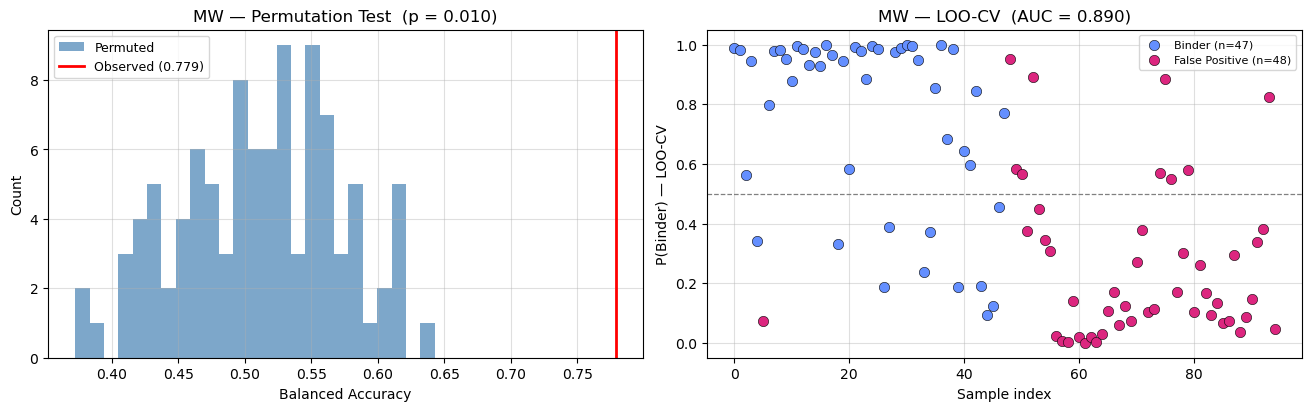

In [4]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
df        = load_feat_table(FEAT_TABLE)
sequences = df["sequence"].tolist()
groups    = df["group"].tolist()
seq_ids   = df["name"].tolist() if "name" in df.columns else [f"seq{i}" for i in range(len(df))]
y         = np.array([BINARY_LABEL[g] for g in groups])
print(f"Binary class counts:  Binder={y.sum()}  Non-binder={(y==0).sum()}")

# ── 2. Fold composition ───────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print(f"\n--- Fold composition (n_splits={N_SPLITS}) ---")
for fold, (tr, te) in enumerate(cv.split(sequences, y)):
    print(f"  Fold {fold+1}: train = {y[tr].sum()} binders / {(y[tr]==0).sum()} nonbinders  |  "
          f"test = {y[te].sum()} binders / {(y[te]==0).sum()} nonbinders")

# ── 3. Feature dims preview ───────────────────────────────────────────────────
ohe_prev = OHEEncoder().fit(sequences)
pcp_prev = PCPEncoder().fit(sequences)
mw_prev  = MWEncoder(pocket_positions=POCKET_POSITIONS if POCKET_POSITIONS else None).fit(sequences)
print(f"\nOHE feature dims : {len(ohe_prev.var_pos_)} pos × 20 AAs   = {len(ohe_prev.var_pos_)*20}")
print(f"PCP feature dims : {len(pcp_prev.var_pos_)} pos × {N_PROPS} props = {len(pcp_prev.var_pos_)*N_PROPS}")
print(f"MW  feature dims : {len(mw_prev.pos_)} pos × 1 scalar = {len(mw_prev.pos_)}")

# ── 4. CV + permutation tests ─────────────────────────────────────────────────
print("\n--- OHE: running CV ---")
ohe_metrics, ohe_obs, ohe_pval, ohe_perm = run_cv(make_ohe_pipe, sequences, y)
print(ohe_metrics.to_string()); print(f"Permutation p-val: {ohe_pval:.3f}")

print("\n--- PCP: running CV ---")
pcp_metrics, pcp_obs, pcp_pval, pcp_perm = run_cv(make_pcp_pipe, sequences, y)
print(pcp_metrics.to_string()); print(f"Permutation p-val: {pcp_pval:.3f}")

print("\n--- MW: running CV ---")
mw_metrics, mw_obs, mw_pval, mw_perm = run_cv(make_mw_pipe, sequences, y)
print(mw_metrics.to_string()); print(f"Permutation p-val: {mw_pval:.3f}")

# ── 5. LOO-CV ─────────────────────────────────────────────────────────────────
print("\n--- Running LOO-CV for all three encodings ---")
ohe_loocv = run_loocv(make_ohe_pipe, sequences, y)
pcp_loocv = run_loocv(make_pcp_pipe, sequences, y)
mw_loocv  = run_loocv(make_mw_pipe,  sequences, y)

ohe_loocv_auc = roc_auc_score(y, ohe_loocv)
pcp_loocv_auc = roc_auc_score(y, pcp_loocv)
mw_loocv_auc  = roc_auc_score(y, mw_loocv)
print(f"OHE LOO-CV AUC: {ohe_loocv_auc:.4f}")
print(f"PCP LOO-CV AUC: {pcp_loocv_auc:.4f}")
print(f"MW  LOO-CV AUC: {mw_loocv_auc:.4f}")

# ── 6. Save combined LOO-CV predictions ──────────────────────────────────────
loocv_df = pd.DataFrame({
    "seq_id":       seq_ids,
    "group":        groups,
    "binary_y":     y,
    "p_binder_ohe": ohe_loocv.round(3),
    "correct_ohe":  ((ohe_loocv >= 0.5).astype(int) == y),
    "p_binder_pcp": pcp_loocv.round(3),
    "correct_pcp":  ((pcp_loocv >= 0.5).astype(int) == y),
    "p_binder_mw":  mw_loocv.round(3),
    "correct_mw":   ((mw_loocv  >= 0.5).astype(int) == y),
})
loocv_df.to_csv(os.path.join(OUT_DIR, "loocv_predictions_all.csv"), index=False)

# ── 7. Feature importances (full-dataset fit) ─────────────────────────────────
ohe_pipe_full = make_ohe_pipe().fit(sequences, y)
pcp_pipe_full = make_pcp_pipe().fit(sequences, y)
mw_pipe_full  = make_mw_pipe().fit(sequences, y)

feature_importance_plot(ohe_pipe_full, "OHE", "ohe", n_per_pos=len(AA_ORDER))
feature_importance_plot(pcp_pipe_full, "PCP", "pcp", n_per_pos=N_PROPS)
feature_importance_plot(mw_pipe_full,  "MW",  "mw",  n_per_pos=1)

# ── 8. Individual permutation + LOO-CV plots ──────────────────────────────────
for label, loocv_proba, auc, obs, perm_scores, pval in [
    ("OHE", ohe_loocv, ohe_loocv_auc, ohe_obs, ohe_perm, ohe_pval),
    ("PCP", pcp_loocv, pcp_loocv_auc, pcp_obs, pcp_perm, pcp_pval),
    ("MW",  mw_loocv,  mw_loocv_auc,  mw_obs,  mw_perm,  mw_pval),
]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    # Permutation test
    axes[0].hist(perm_scores, bins=25, color="steelblue", alpha=0.7, label="Permuted")
    axes[0].axvline(obs, color="red", lw=2, label=f"Observed ({obs:.3f})")
    axes[0].set_xlabel("Balanced Accuracy")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{label} — Permutation Test  (p = {pval:.3f})")
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.4)

    # LOO-CV scatter
    for grp, color in GROUP_COLORS.items():
        mask = np.array(groups) == grp
        if mask.sum() == 0: continue
        axes[1].scatter(
            np.where(mask)[0], loocv_proba[mask],
            color=color, label=f"{DISPLAY_LABEL[grp]} (n={mask.sum()})",
            s=55, zorder=3, edgecolors="k", linewidths=0.4,
        )
    axes[1].axhline(0.5, color="gray", ls="--", lw=0.9)
    axes[1].set_ylabel("P(Binder) — LOO-CV")
    axes[1].set_xlabel("Sample index")
    axes[1].set_title(f"{label} — LOO-CV  (AUC = {auc:.3f})")
    axes[1].legend(fontsize=8, loc="upper right")
    axes[1].grid(True, alpha=0.4)

    fig.savefig(os.path.join(OUT_DIR, f"individual_{label.lower()}.png"), dpi=150)
    plt.show()


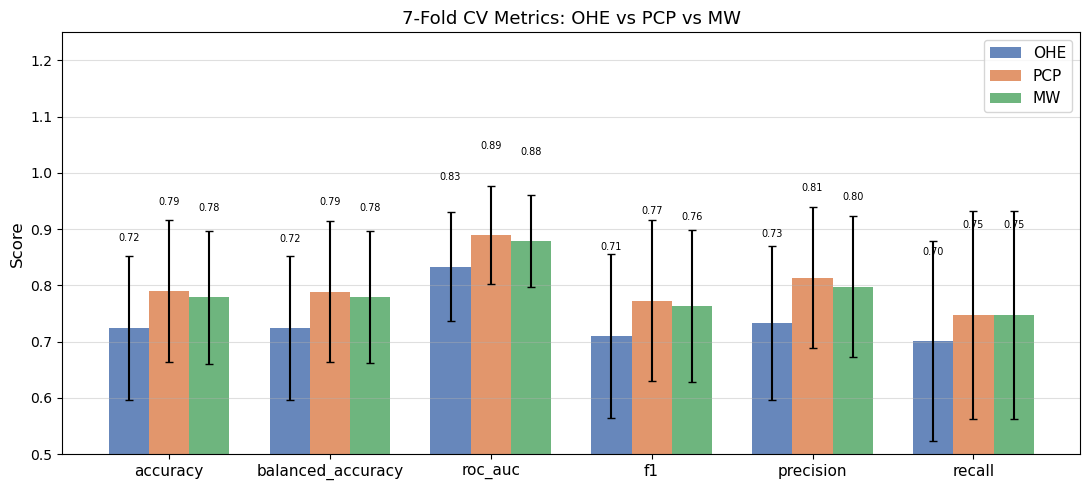

/Users/ivanatang/miniforge3/envs/biosensors/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ivanatang/miniforge3/envs/biosensors/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ivanatang/miniforge3/envs/biosensors/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


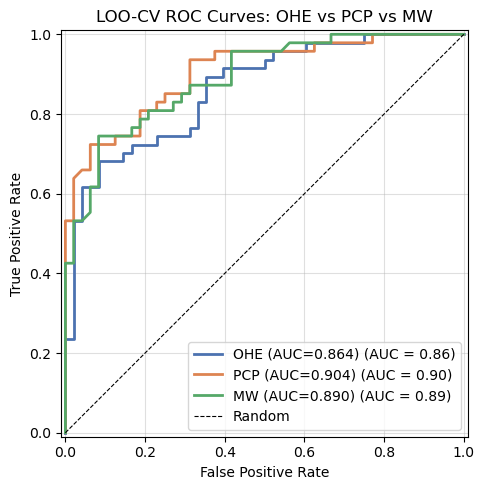

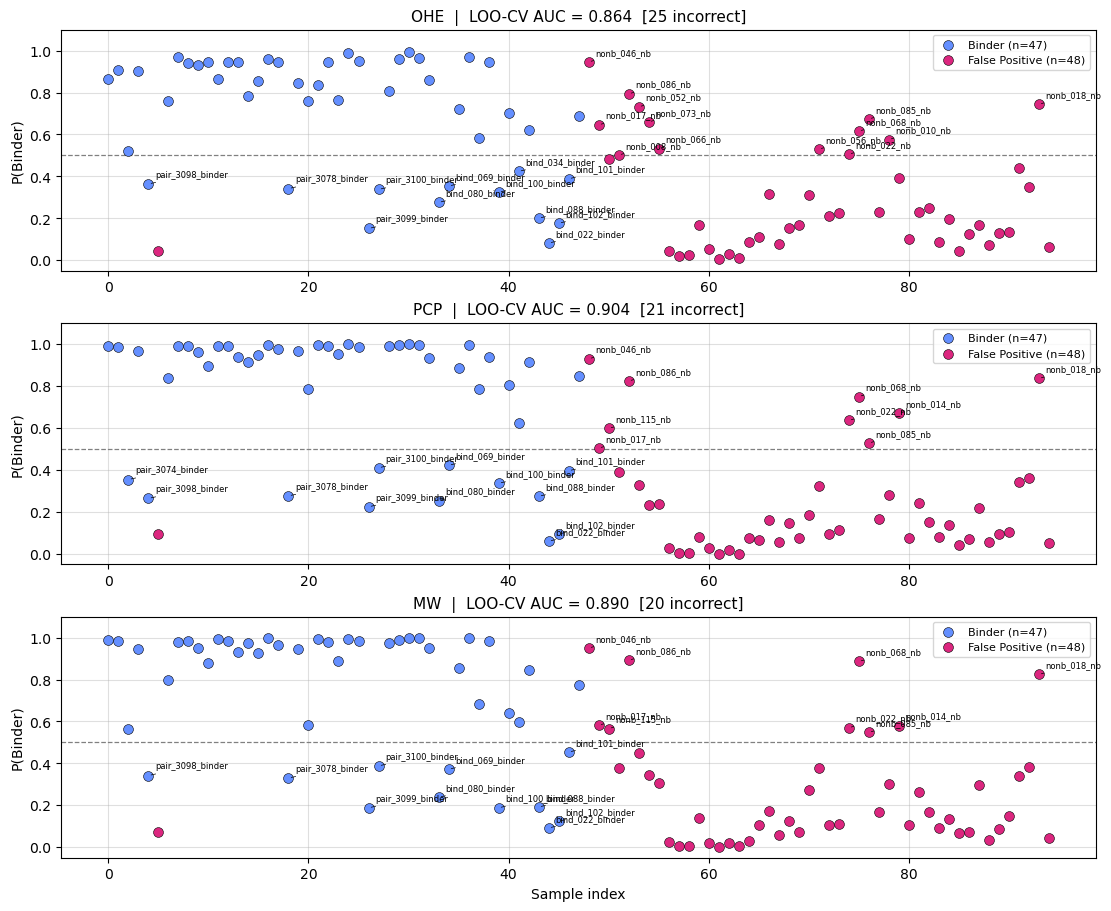

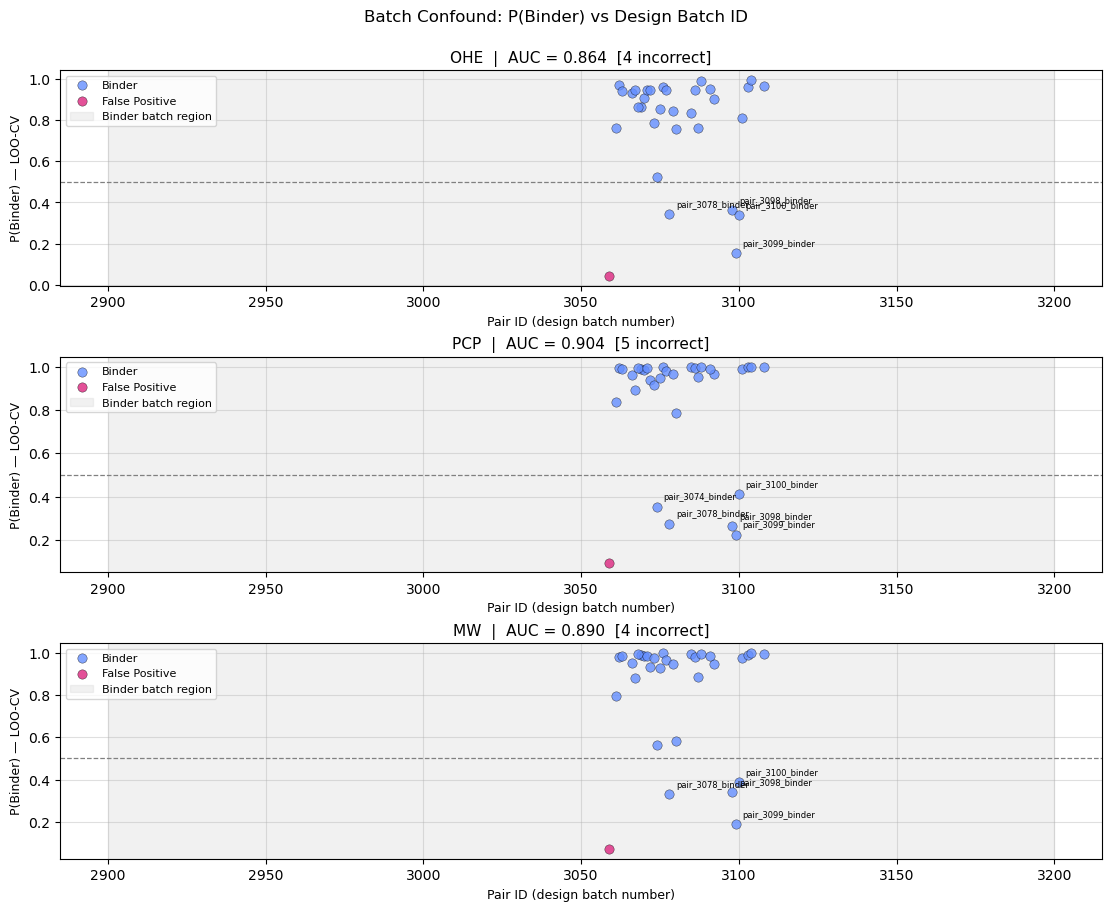


Sequence Baseline Comparison Summary
Metric                   OHE Mean  OHE SD   PCP Mean  PCP SD    MW Mean   MW SD
------------------------------------------------------------------------
accuracy                    0.725   0.128      0.790   0.127      0.779    0.118
balanced_accuracy           0.724   0.128      0.789   0.126      0.779    0.117
roc_auc                     0.833   0.097      0.889   0.087      0.879    0.082
f1                          0.710   0.145      0.773   0.143      0.763    0.135
precision                   0.733   0.137      0.814   0.125      0.798    0.125
recall                      0.701   0.178      0.748   0.185      0.748    0.185
------------------------------------------------------------------------
Permutation p-val           0.010              0.010              0.010
LOO-CV AUC                 0.8639             0.9040             0.8901

All outputs written to: /Users/ivanatang/Developer/biosensors/sequence_baselines/ngs_observed


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Comparison plots: OHE vs PCP vs MW
# ══════════════════════════════════════════════════════════════════════════════

results = {
    "OHE": {"metrics": ohe_metrics, "obs": ohe_obs, "pval": ohe_pval,
            "perm": ohe_perm, "loocv": ohe_loocv, "auc": ohe_loocv_auc},
    "PCP": {"metrics": pcp_metrics, "obs": pcp_obs, "pval": pcp_pval,
            "perm": pcp_perm, "loocv": pcp_loocv, "auc": pcp_loocv_auc},
    "MW":  {"metrics": mw_metrics,  "obs": mw_obs,  "pval": mw_pval,
            "perm": mw_perm,  "loocv": mw_loocv,  "auc": mw_loocv_auc},
}

# ── Plot 1: Metrics comparison bar chart ──────────────────────────────────────
metric_names = list(ohe_metrics.index)
x     = np.arange(len(metric_names))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(11, 5))
for (label, res), offset in zip(results.items(), offsets):
    bars = ax.bar(x + offset, res["metrics"]["Mean"], width,
                  yerr=res["metrics"]["SD"], capsize=3,
                  color=ENC_COLORS[label], alpha=0.85, label=label)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.5, 1.25)
ax.set_title(f"{N_SPLITS}-Fold CV Metrics: OHE vs PCP vs MW", fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "baseline_metrics_comparison.png"), dpi=300)
plt.show()

# ── Plot 2: ROC curves overlaid ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for label, res in results.items():
    RocCurveDisplay.from_predictions(
        y, res["loocv"], ax=ax,
        name=f"{label} (AUC={res['auc']:.3f})",
        color=ENC_COLORS[label], lw=2,
    )
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random")
ax.set_title("LOO-CV ROC Curves: OHE vs PCP vs MW", fontsize=12)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "baseline_roc_comparison.png"), dpi=150)
plt.show()

# ── Plot 3: LOO-CV scatter stacked (all three) ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9), constrained_layout=True)
for ax, (label, res) in zip(axes, results.items()):
    for grp, color in GROUP_COLORS.items():
        mask = np.array(groups) == grp
        if mask.sum() == 0: continue
        ax.scatter(
            np.where(mask)[0], res["loocv"][mask],
            color=color, label=f"{DISPLAY_LABEL[grp]} (n={mask.sum()})",
            s=50, zorder=3, edgecolors="k", linewidths=0.4,
        )
    # Annotate incorrect predictions with their sequence ID
    wrong_mask = (res["loocv"] >= 0.5).astype(int) != y
    for i in np.where(wrong_mask)[0]:
        ax.annotate(
            seq_ids[i],
            xy=(i, res["loocv"][i]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=6, color="black", zorder=5,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
        )
    ax.axhline(0.5, color="gray", ls="--", lw=0.9)
    ax.set_ylabel("P(Binder)", fontsize=10)
    ax.set_title(f"{label}  |  LOO-CV AUC = {res['auc']:.3f}  "
                 f"[{wrong_mask.sum()} incorrect]", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.4)
axes[2].set_xlabel("Sample index", fontsize=10)
fig.savefig(os.path.join(OUT_DIR, "baseline_loocv_comparison.png"), dpi=300)
plt.show()

# ── Plot 4: Batch confound — P(Binder) vs design batch ID ─────────────────────
# Extract numeric pair ID from seq_id; seq_XX entries are assigned NaN
def extract_pair_id(name):
    m = re.search(r'pair_(\d+)', str(name))
    return int(m.group(1)) if m else np.nan

pair_ids = np.array([extract_pair_id(s) for s in seq_ids], dtype=float)
has_pair = ~np.isnan(pair_ids)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), constrained_layout=True)
fig.suptitle("Batch Confound: P(Binder) vs Design Batch ID\n", fontsize=12)
for ax, (label, res) in zip(axes, results.items()):
    for grp, color in GROUP_COLORS.items():
        mask = (np.array(groups) == grp) & has_pair
        if mask.sum() == 0: continue
        ax.scatter(
            pair_ids[mask], res["loocv"][mask],
            color=color, label=f"{DISPLAY_LABEL[grp]}",
            s=45, alpha=0.8, edgecolors="k", linewidths=0.3, zorder=3,
        )
    # Annotate incorrect predictions that have a pair ID
    wrong_and_has_pair = has_pair & ((res["loocv"] >= 0.5).astype(int) != y)
    for i in np.where(wrong_and_has_pair)[0]:
        ax.annotate(
            seq_ids[i],
            xy=(pair_ids[i], res["loocv"][i]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=6, color="black", zorder=5,
        )
    ax.axhline(0.5, color="gray", ls="--", lw=0.9)
    ax.axvspan(2900, 3200, color="lightgray", alpha=0.3, label="Binder batch region")
    ax.set_ylabel("P(Binder) — LOO-CV", fontsize=9)
    ax.set_xlabel("Pair ID (design batch number)", fontsize=9)
    ax.set_title(f"{label}  |  AUC = {res['auc']:.3f}  "
                 f"[{wrong_and_has_pair.sum()} incorrect]", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.4)
fig.savefig(os.path.join(OUT_DIR, "baseline_results.png"), dpi=300)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("Sequence Baseline Comparison Summary")
print("="*72)
print(f"{'Metric':<22} {'OHE Mean':>10} {'OHE SD':>7} {'PCP Mean':>10} {'PCP SD':>7} {'MW Mean':>10} {'MW SD':>7}")
print("-"*72)
for metric in metric_names:
    print(f"{metric:<22}"
          f" {ohe_metrics.loc[metric,'Mean']:>10.3f} {ohe_metrics.loc[metric,'SD']:>7.3f}"
          f" {pcp_metrics.loc[metric,'Mean']:>10.3f} {pcp_metrics.loc[metric,'SD']:>7.3f}"
          f" {mw_metrics.loc[metric,'Mean']:>10.3f}  {mw_metrics.loc[metric,'SD']:>7.3f}")
print("-"*72)
print(f"{'Permutation p-val':<22} {ohe_pval:>10.3f} {'':>7} {pcp_pval:>10.3f} {'':>7} {mw_pval:>10.3f}")
print(f"{'LOO-CV AUC':<22} {ohe_loocv_auc:>10.4f} {'':>7} {pcp_loocv_auc:>10.4f} {'':>7} {mw_loocv_auc:>10.4f}")
print(f"\nAll outputs written to: {OUT_DIR}")


=== Single-position rules ===
           n_predicted_binder  balanced_accuracy     f1  precision  recall
rule                                                                      
pos81==D                   47              0.768  0.766      0.766   0.766
pos83==L                   50              0.758  0.763      0.740   0.787
pos92==M                   50              0.758  0.763      0.740   0.787
pos141==K                  58              0.654  0.686      0.621   0.766
pos159==I                  56              0.590  0.621      0.571   0.681
pos163==G                  56              0.590  0.621      0.571   0.681

=== Pairwise rules ===
                       n_predicted_binder  balanced_accuracy     f1  precision  recall
rule                                                                                  
pos81==D & pos141==K                   38              0.778  0.753      0.842   0.681
pos83==L & pos141==K                   40              0.778  0.759      0.825   0.70

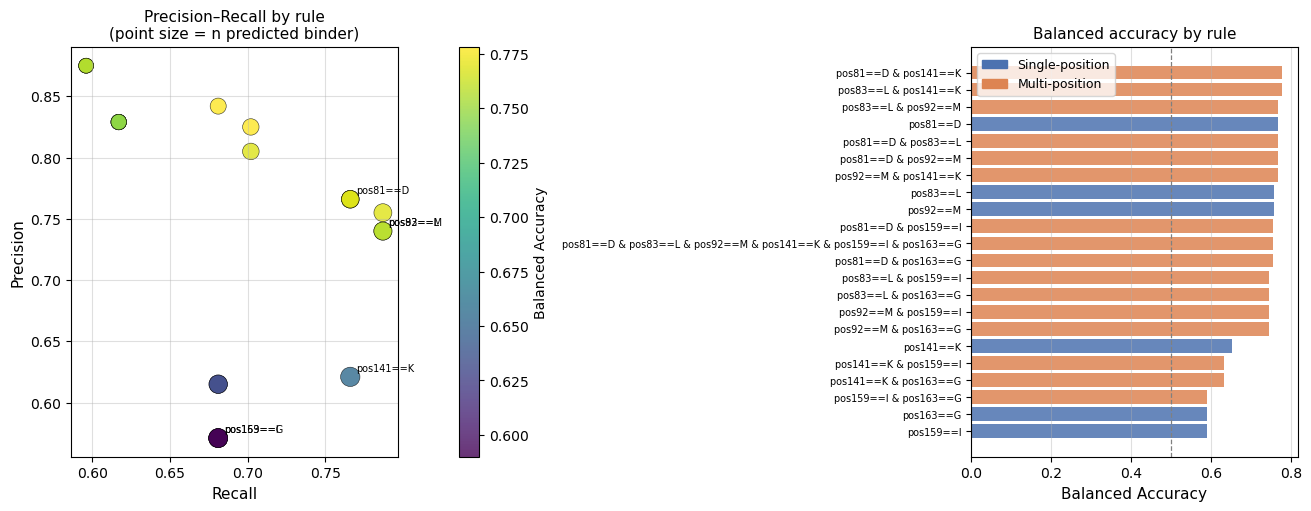


=== Per-sequence breakdown: best single rule pos81==D ===

Incorrect predictions:
          seq_id     group AA_at_pos
pair_3098_binder    binder         L
pair_3100_binder    binder         L
 bind_099_binder    binder         L
 bind_100_binder    binder         L
 bind_110_binder    binder         L
 bind_034_binder    binder         L
 bind_088_binder    binder         I
 bind_022_binder    binder         L
 bind_102_binder    binder         L
 bind_101_binder    binder         L
 bind_083_binder    binder         L
     nonb_046_nb nonbinder         D
     nonb_017_nb nonbinder         D
     nonb_052_nb nonbinder         D
     nonb_073_nb nonbinder         D
     nonb_066_nb nonbinder         D
     nonb_071_nb nonbinder         D
     nonb_022_nb nonbinder         D
     nonb_068_nb nonbinder         D
     nonb_085_nb nonbinder         D
     nonb_051_nb nonbinder         D
     nonb_010_nb nonbinder         D


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Rule-based classifier: positional motif rules
# ══════════════════════════════════════════════════════════════════════════════
from itertools import combinations
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score

# ── Discriminating positions and their binder motif AA (from frequency analysis)
MOTIF_RULES = {
    81:  "D",
    83:  "L",
    92:  "M",
    141: "K",
    159: "I",
    163: "G",
}

# ── Load sequences and labels (reuse from earlier cells)
# sequences, groups, seq_ids, y already defined

def apply_rule(sequences, positions_aas):
    """
    Predict binder=1 if ALL specified (position, AA) conditions are met.
    positions_aas: dict of {position (1-indexed): required_AA}
    """
    preds = []
    for seq in sequences:
        match = all(seq[pos - 1].upper() == aa
                    for pos, aa in positions_aas.items())
        preds.append(1 if match else 0)
    return np.array(preds)

def evaluate_rule(y_true, y_pred, rule_label):
    return {
        "rule":              rule_label,
        "n_predicted_binder": y_pred.sum(),
        "balanced_accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1":                round(f1_score(y_true, y_pred, zero_division=0), 3),
        "precision":         round(precision_score(y_true, y_pred, zero_division=0), 3),
        "recall":            round(recall_score(y_true, y_pred, zero_division=0), 3),
    }

# ── 1. Single-position rules ──────────────────────────────────────────────────
print("=== Single-position rules ===")
single_results = []
for pos, aa in MOTIF_RULES.items():
    y_pred = apply_rule(sequences, {pos: aa})
    single_results.append(evaluate_rule(y, y_pred, f"pos{pos}=={aa}"))

single_df = pd.DataFrame(single_results).set_index("rule")
print(single_df.to_string())

# ── 2. All pairwise combinations ──────────────────────────────────────────────
print("\n=== Pairwise rules ===")
pair_results = []
for (p1, a1), (p2, a2) in combinations(MOTIF_RULES.items(), 2):
    y_pred = apply_rule(sequences, {p1: a1, p2: a2})
    pair_results.append(evaluate_rule(y, y_pred, f"pos{p1}=={a1} & pos{p2}=={a2}"))

pair_df = pd.DataFrame(pair_results).set_index("rule")
print(pair_df.sort_values("balanced_accuracy", ascending=False).to_string())

# ── 3. Full motif rule (all positions) ───────────────────────────────────────
print("\n=== Full motif rule (all positions) ===")
y_pred_full = apply_rule(sequences, MOTIF_RULES)
full_result  = evaluate_rule(y, y_pred_full, " & ".join(f"pos{p}=={a}"
                                                         for p, a in MOTIF_RULES.items()))
print(pd.Series(full_result).to_string())

# ── 4. Visualise precision-recall trade-off across rules ──────────────────────
all_results = single_results + pair_results + [full_result]
results_df  = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Precision vs Recall scatter, sized by n_predicted_binder
sc = axes[0].scatter(
    results_df["recall"], results_df["precision"],
    s=results_df["n_predicted_binder"] * 3 + 20,
    c=results_df["balanced_accuracy"],
    cmap="viridis", alpha=0.8, edgecolors="k", linewidths=0.4,
)
# Label single-position rules
for _, row in results_df[results_df["rule"].str.count("&") == 0].iterrows():
    axes[0].annotate(row["rule"], xy=(row["recall"], row["precision"]),
                     xytext=(4, 4), textcoords="offset points", fontsize=7)
plt.colorbar(sc, ax=axes[0], label="Balanced Accuracy")
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].set_title("Precision–Recall by rule\n(point size = n predicted binder)", fontsize=11)
axes[0].grid(True, alpha=0.4)

# Balanced accuracy bar chart, sorted
results_df_sorted = results_df.sort_values("balanced_accuracy", ascending=True)
colors = ["#4C72B0" if "&" not in r else "#DD8452"
          for r in results_df_sorted["rule"]]
axes[1].barh(range(len(results_df_sorted)), results_df_sorted["balanced_accuracy"],
             color=colors, alpha=0.85)
axes[1].set_yticks(range(len(results_df_sorted)))
axes[1].set_yticklabels(results_df_sorted["rule"], fontsize=7)
axes[1].set_xlabel("Balanced Accuracy", fontsize=11)
axes[1].set_title("Balanced accuracy by rule", fontsize=11)
axes[1].axvline(0.5, color="gray", ls="--", lw=0.9, label="Random")
legend_handles = [
    mpatches.Patch(color="#4C72B0", label="Single-position"),
    mpatches.Patch(color="#DD8452", label="Multi-position"),
]
axes[1].legend(handles=legend_handles, fontsize=9)
axes[1].grid(True, alpha=0.4, axis="x")
plt.savefig(os.path.join(OUT_DIR, "motif_rule_classifier.png"), dpi=150)
plt.show()

# ── 5. Per-sequence breakdown for the single best rule ───────────────────────
best_rule_pos, best_rule_aa = max(
    MOTIF_RULES.items(),
    key=lambda x: balanced_accuracy_score(y, apply_rule(sequences, {x[0]: x[1]}))
)
y_pred_best = apply_rule(sequences, {best_rule_pos: best_rule_aa})
print(f"\n=== Per-sequence breakdown: best single rule pos{best_rule_pos}=={best_rule_aa} ===")
breakdown = pd.DataFrame({
    "seq_id":    seq_ids,
    "group":     groups,
    "true_y":    y,
    "predicted": y_pred_best,
    "correct":   y_pred_best == y,
    "AA_at_pos": [seq[best_rule_pos - 1].upper() for seq in sequences],
})
print("\nIncorrect predictions:")
print(breakdown[~breakdown["correct"]][["seq_id","group","AA_at_pos"]].to_string(index=False))
breakdown.to_csv(os.path.join(OUT_DIR, "motif_rule_predictions.csv"), index=False)